In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import joblib, json, os

In [2]:
df = pd.read_csv('creditcard.csv')
scaler = StandardScaler()
df['Time'] = scaler.fit_transform(df[['Time']])
df['Amount'] = scaler.fit_transform(df[['Amount']])
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [3]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(227845, 30) (56962, 30)


In [4]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_sm).value_counts().to_dict())

Before SMOTE: {0: 227451, 1: 394}
After SMOTE:  {0: 227451, 1: 227451}


In [ ]:

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)  # X_train, not X_train_sm
print("Training done.")

Training done.


In [9]:
from sklearn.metrics import precision_recall_curve

y_prob = rf_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

y_pred_tuned = (y_prob >= best_threshold).astype(int)
print(f"Best threshold: {best_threshold:.3f}")
print(classification_report(y_test, y_pred_tuned))

Best threshold: 0.410
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.86      0.89        98

    accuracy                           1.00     56962
   macro avg       0.97      0.93      0.95     56962
weighted avg       1.00      1.00      1.00     56962



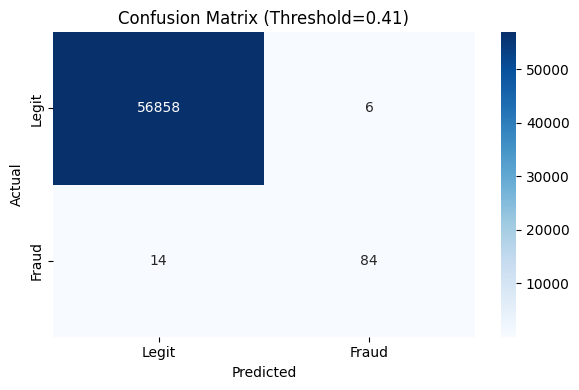

 Caught frauds:       84 / 98
 Missed frauds:       14 / 98
 False alarms:        6 (legit flagged as fraud)
 Correctly cleared:   56858

ROC-AUC:          0.9630
Average Precision: 0.8734


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title(f'Confusion Matrix (Threshold={best_threshold:.2f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()

plt.show()

# Numbers in plain English
tn, fp, fn, tp = cm.ravel()
print(f" Caught frauds:       {tp} / {tp+fn}")
print(f" Missed frauds:       {fn} / {tp+fn}")
print(f" False alarms:        {fp} (legit flagged as fraud)")
print(f" Correctly cleared:   {tn}")

# Extra metrics
print(f"\nROC-AUC:          {roc_auc_score(y_test, y_prob):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_prob):.4f}")

In [12]:
os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)

joblib.dump(rf_model, 'models/best_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

json.dump({
    "model": "RandomForest",
    "threshold": round(float(best_threshold), 3),
    "features": list(X.columns)
}, open('models/metadata.json', 'w'), indent=2)

print("Saved:", os.listdir('models'))

Saved: ['best_model.pkl', 'metadata.json', 'scaler.pkl']


In [18]:
import requests

# Take a real fraud transaction from your test set
fraud_idx = y_test[y_test == 1].index[0]
transaction = X_test.loc[fraud_idx].to_dict()

r = requests.post('http://localhost:5000/predict', json=transaction)
print("Actual label: FRAUD")
print(r.json())

Actual label: FRAUD
{'fraud_probability': 0.88, 'is_fraud': True, 'risk_level': 'HIGH'}


In [19]:
legit_idx = y_test[y_test == 0].index[0]
transaction = X_test.loc[legit_idx].to_dict()

r = requests.post('http://localhost:5000/predict', json=transaction)
print("Actual label: LEGIT")
print(r.json())

Actual label: LEGIT
{'fraud_probability': 0.01, 'is_fraud': False, 'risk_level': 'LOW'}
